In [2]:
import numpy as np
import mpmath as mp
from mpmath import ellippi as mpmath_ellippi
from mpmath import ellipf as mpmath_ellipf
from mpmath import ellipk as mpmath_ellipk
from mpmath import ellipf as mpmath_ellipf
from mpmath import elliprj, elliprf 
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.special import ellipkinc, ellipeinc
from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm
from matplotlib.colors import Normalize
plt.style.use('custom_paper')

In [3]:
#set global constants
G = 1
M = 1

In [4]:
def compute_params(a, r0, e, z0, omega, theta0):
    dphi = theta0 - omega
    cosd = np.cos(dphi)
    sind = np.sin(dphi)
    k1 = (1 + e)**2 * (a**2 * (1 - e)**2 + r0**2 + z0**2 - 2 * a * (1 - e) * r0 * cosd)
    k2 = -4 * a * (1 - e) * (1 + e)**2 * r0 * sind
    k3 = 2 * (-1 + e**2) * (a**2 * (-1 + e**2) - r0**2 - z0**2 - 2 * a * e * r0 * cosd)
    k4 = -4 * a * (1 - e)**2 * (1 + e) * r0 * sind          # sign flipped
    k5 = (1 - e)**2 * (a**2 * (1 + e)**2 + r0**2 + z0**2 + 2 * a * (1 + e) * r0 * cosd)
    return dphi, k1, k2, k3, k4, k5    

def compute_roots(k1, k2, k3, k4, k5):
    coeffs = [k5, k4, k3, k2, k1]
    roots = np.roots(coeffs)
    q3 = next(r for r in roots if np.real(r) < 0 and np.imag(r) < 0)  # r1
    q2 = next(r for r in roots if np.real(r) < 0 and np.imag(r) > 0)  # r2
    q4 = next(r for r in roots if np.real(r) > 0 and np.imag(r) < 0)  # r3
    q1 = next(r for r in roots if np.real(r) > 0 and np.imag(r) > 0)  # r4
    return [q3, q2, q4, q1]

def compute_AB(roots):
    roots_sorted = sorted(roots, key=lambda z: (np.real(z), np.imag(z)))
    r1 = roots_sorted[0]
    r3 = roots_sorted[2]
    A1 = np.real(r1)
    B1 = np.abs(np.imag(r1))
    A2 = np.real(r3)
    B2 = np.abs(np.imag(r3))
    return [A1, B1, A2, B2]

def getallparams(params):
    a, r0, e, z0, omega, theta0 = params
    dphi, k1, k2, k3, k4, k5 = compute_params(*params)
    r1, r2, r3, r4 = compute_roots(k1, k2, k3, k4, k5)
    A1,B1,A2,B2 = compute_AB([r1,r2,r3,r4])
    output = [a,r0,e,z0,omega,theta0,dphi,k1,k2,k3,k4,k5,r1,r2,r3,r4,A1,B1,A2,B2]
    return output

In [5]:
def coeff(allparams):
    a,r0,e,z0,omega,theta0,dphi,k1,k2,k3,k4,k5,r1,r2,r3,r4,A1,B1,A2,B2 = allparams
    return -4 / (np.sqrt(k5) * np.abs(r1 - r3))

def sign(allparams, t):
    a, r0, e, z0, omega, theta0, dphi, k1, k2, k3, k4, k5, r1, r2, r3, r4, A1, B1, A2, B2 = allparams    
    prefactor = (np.abs(r1 - r3) * (r1 - r4) * (t - r2)**2) / ((-r1 + r2) * (r2 - r4))
    radicand  = ((r1 - r2)**2 * (r2 - r4)) / ((r1 - r3) * (r1 - r4)**2 * (t - r2)**4)    
    return prefactor * np.sqrt(radicand)

In [6]:
def jump_branch(m, s2, n):
    s  = np.sqrt(s2)
    x = 1 - s2
    y = 1 - n*s2
    p = 1 - m*s2

    beta  = x - y
    gamma = 1 - y
    alpha = p - y
    RJ_sum = 2 * elliprj(beta.real, 0, gamma.real, alpha)
    
    S_full = -(m * (s**3) / 3) * RJ_sum

    c2 = 1 - s2
    Y  = 1 - n*s2
    RF = elliprf(c2,Y,1)
    
    return S_full - 2*s*RF.real

def jump_pole(m, s2, n):
    s = np.sqrt(s2)

    x = 1 - s2
    y = 1 - n*s2
    p = 1 - m*s2

    a = -p.real 
    Delta = 3*np.pi*1j / np.sqrt((a + x) * (a + y) * (a + 1)) 
    return (m * s**3 * Delta) / 3

In [7]:
def split1(allparams):
    a,r0,e,z0,omega,theta0,dphi,k1,k2,k3,k4,k5,r1,r2,r3,r4,A1,B1,A2,B2 = allparams
    split1 = -(1 / (2 * (A1 - A2))) * (-A1**2 + A2**2 - B1**2 + B2**2 - np.sqrt(((A1 - A2)**2 + B1**2)**2 + 2 * (A1 - A2 - B1) * (A1 - A2 + B1) * B2**2 + B2**4))
    return split1

def split3(allparams):
    a,r0,e,z0,omega,theta0,dphi,k1,k2,k3,k4,k5,r1,r2,r3,r4,A1,B1,A2,B2 = allparams
    split = -(1 / (2 * (A1 - A2))) * (-A1**2 + A2**2 - B1**2 + B2**2 + np.sqrt(((A1 - A2)**2 + B1**2)**2 + 2 * (A1 - A2 - B1) * (A1 - A2 + B1) * B2**2 + B2**4))
    return split

def split2(allparams):
    a,r0,e,z0,omega,theta0,dphi,k1,k2,k3,k4,k5,r1,r2,r3,r4,A1,B1,A2,B2 = allparams
    numerator = -1 + A1**2 + B1**2 - np.sqrt((1 + A1**2)**2 + 2 * (-1 + A1**2) * B1**2 + B1**4)
    denominator = 2 * A1
    split2 = numerator / denominator
    return split2

In [8]:
def elliptic_wier_integrand(allparams,t):
    a,r0,e,z0,omega,theta0,dphi,k1,k2,k3,k4,k5,r1,r2,r3,r4,A1,B1,A2,B2 = allparams
    c = coeff(allparams)
    sgn = sign(allparams, t)
    
    s = ((r2 - r4) * (-(r1 - t))) / ((r1 - r4) * (-(r2 - t)))
    phi = np.arcsin(np.sqrt(s))
    m = -((r2 - r3) * (r1 - r4)) / ((-r1 + r3) * (r2 - r4))
    n1  = ((-1j + r2) * (r1 - r4)) / ((-1j + r1) * (r2 - r4))
    n2  = ((1j + r2) * (r1 - r4)) / ((1j + r1) * (r2 - r4))
    
    t3 = split3(allparams)
    t2 = split2(allparams)
    t1  = split1(allparams)
    
    s2_t3 = ((r2 - r4) * (-(r1 - t3))) / ((r1 - r4) * (-(r2 - t3)))
    s2_t2 = ((r2 - r4) * (-(r1 - t2))) / ((r1 - r4) * (-(r2 - t2)))
    
    jump_val_F =  -2*mpmath_ellipk(m).real 
    jump1_pi1 = jump_branch(n1, s2_t3, m)
    jump1_pi2 = jump_branch(n2, s2_t3, m)
    jump2_pi2 = jump_pole(n2, s2_t2, m)
    
    coeff_f1 = (1+e*(2/(1+r2**2) -1))
    coeff_pi1 = (((1j * e) * (r1 - r2)) / ((-1j + r1) * (-1j + r2)))
    coeff_pi2 = -(((1j * e) * (r1 - r2)) / ((1j + r1) * (1j + r2)))
    
    f1 = mpmath_ellipf(phi,m)
    pi1 = mpmath_ellippi(n1, phi, m)
    pi2 = mpmath_ellippi(n2, phi, m)
    
    cf   = np.select([t < t1, (t >= t1) & (t < t2), (t >= t2) & (t < t3), t >= t3], [f1, -f1, -f1, f1 + jump_val_F], default=np.nan)
    cpi1 = np.select([t < t1, (t >= t1) & (t < t2), (t >= t2) & (t < t3), t >= t3], [pi1 , -pi1 ,-pi1 , pi1 + jump1_pi1], default=np.nan)
    cpi2 = np.select([t < t1, (t >= t1) & (t < t2), (t >= t2) & (t < t3), t >= t3], [pi2 , -pi2 , -pi2 - jump2_pi2, pi2 + jump1_pi2 - jump2_pi2], default=np.nan)

    return sgn, f1, pi1, pi2, cf, cpi1, cpi2


In [9]:
a, r0, e, z0, omega, theta0 = 1.0, 0.5, 0.5, 0.1, 2.0, 0.0 
allparams  = getallparams([a, r0, e, z0, omega, theta0])
t_vals = np.linspace(-10,10,10000)

In [10]:
t1  = split1(allparams)
t2  = split2(allparams)
t3  = split3(allparams)

sgn_real, sgn_imag = [], []
f1_real, f1_imag = [], []
pi1_real, pi1_imag = [], []
pi2_real, pi2_imag = [], []

cf1_real, cf1_imag = [], []
cpi1_real, cpi1_imag = [], []
cpi2_real, cpi2_imag = [], []

for t in t_vals:
    sgn, f1, pi1, pi2, cf1, cpi1, cpi2 = elliptic_wier_integrand(allparams,t)

    sgn_real.append(sgn.real)
    f1_real.append(f1.real)
    f1_imag.append(f1.imag)
    pi1_real.append(pi1.real)
    pi1_imag.append(pi1.imag)
    pi2_real.append(pi2.real)
    pi2_imag.append(pi2.imag)
    
    cf1_real.append(np.complex128(cf1).real)
    cf1_imag.append(np.complex128(cf1).imag)
    cpi1_real.append(np.complex128(cpi1).real)
    cpi1_imag.append(np.complex128(cpi1).imag)
    cpi2_real.append(np.complex128(cpi2).real)
    cpi2_imag.append(np.complex128(cpi2).imag)

In [11]:
sgn_real = np.asarray(sgn_real, dtype=float)
sgn_imag = np.asarray(sgn_imag, dtype=float)
f1_real  = np.asarray(f1_real,  dtype=float)
f1_imag  = np.asarray(f1_imag,  dtype=float)
pi1_real = np.asarray(pi1_real, dtype=float)
pi1_imag = np.asarray(pi1_imag, dtype=float)
pi2_real = np.asarray(pi2_real, dtype=float)
pi2_imag = np.asarray(pi2_imag, dtype=float)
cf1_real  = np.asarray(cf1_real,  dtype=float)
cf1_imag  = np.asarray(cf1_imag,  dtype=float)
cpi1_real = np.asarray(cpi1_real, dtype=float)
cpi1_imag = np.asarray(cpi1_imag, dtype=float)
cpi2_real = np.asarray(cpi2_real, dtype=float)
cpi2_imag = np.asarray(cpi2_imag, dtype=float)

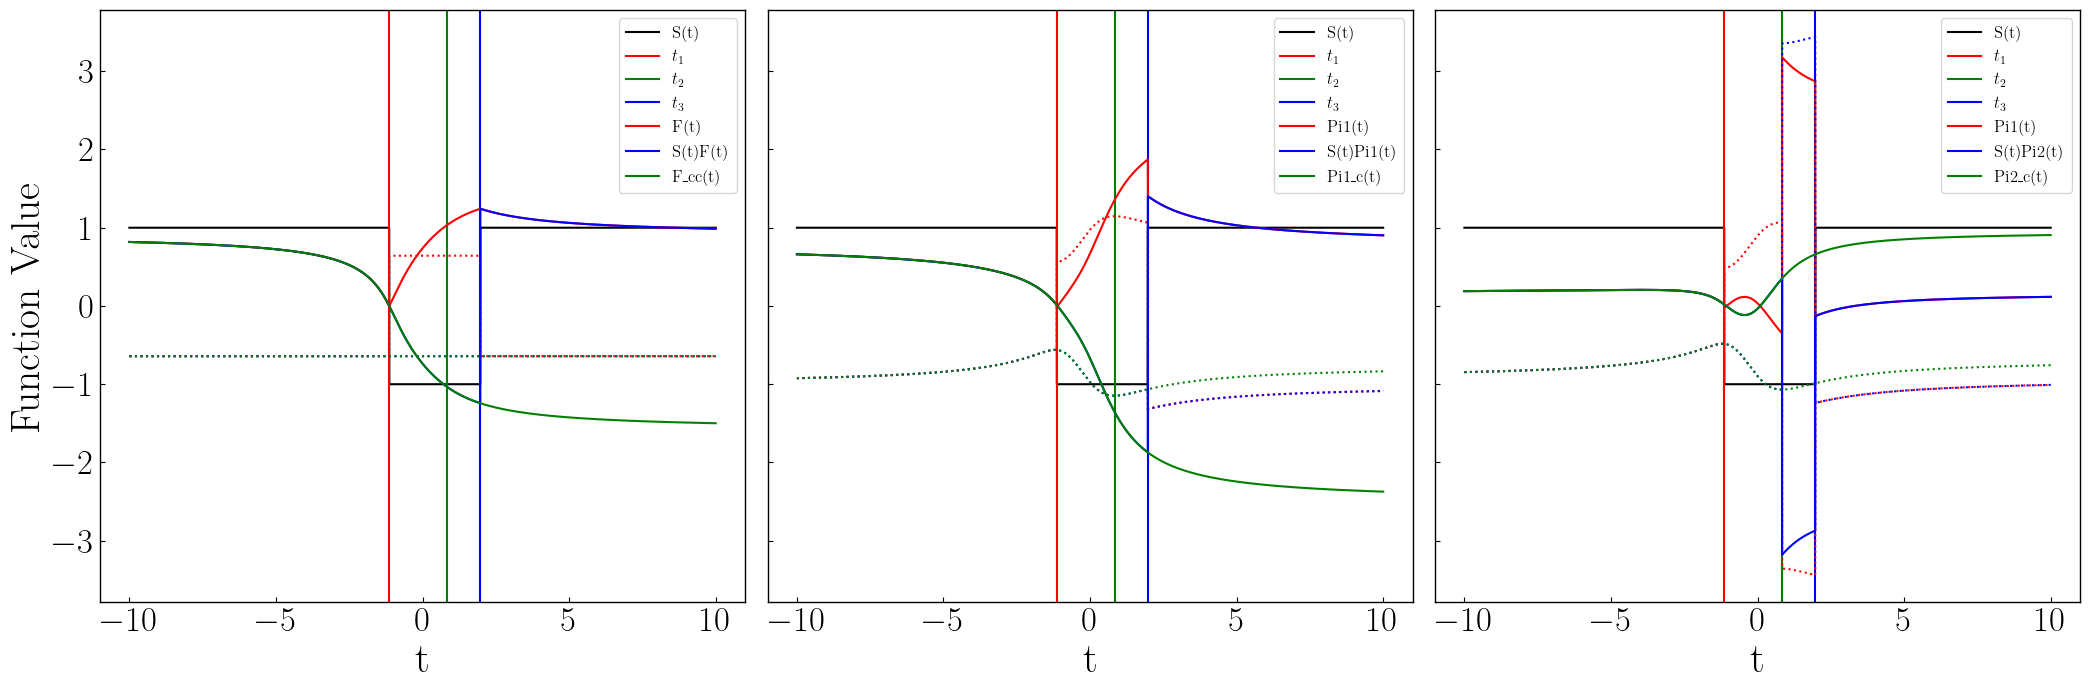

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(21,7),sharey=True)

for i in range(3):
    ax[i].plot(t_vals, sgn_real, color='black', label='S(t)')
    ax[i].axvline(t1, color='r', label=r'$t_1$')
    ax[i].axvline(t2, color='g', label=r'$t_2$')
    ax[i].axvline(t3, color='b', label=r'$t_3$')


ax[0].plot(t_vals, f1_real, color='red', label='F(t)')
ax[0].plot(t_vals, f1_imag, color='red', linestyle='dotted')
ax[1].plot(t_vals, pi1_real, color='red', label='Pi1(t)')
ax[1].plot(t_vals, pi1_imag, color='red', linestyle='dotted')
ax[2].plot(t_vals, pi2_real, color='red', label='Pi1(t)')
ax[2].plot(t_vals, pi2_imag, color='red', linestyle='dotted')


ax[0].plot(t_vals, sgn_real*f1_real, color='blue', label='S(t)F(t)')
ax[0].plot(t_vals, sgn_real*f1_imag, color='blue', linestyle='dotted')
ax[1].plot(t_vals, sgn_real*pi1_real, color='blue', label='S(t)Pi1(t)')
ax[1].plot(t_vals, sgn_real*pi1_imag, color='blue', linestyle='dotted')
ax[2].plot(t_vals, sgn_real*pi2_real, color='blue', label='S(t)Pi2(t)')
ax[2].plot(t_vals, sgn_real*pi2_imag, color='blue', linestyle='dotted')

ax[0].plot(t_vals, cf1_real, color='green', label='F_cc(t)')
ax[0].plot(t_vals, cf1_imag, color='green', linestyle='dotted')
ax[1].plot(t_vals, cpi1_real, color='green', label='Pi1_c(t)')
ax[1].plot(t_vals, cpi1_imag, color='green', linestyle='dotted')
ax[2].plot(t_vals, cpi2_real, color='green', label='Pi2_c(t)')
ax[2].plot(t_vals, cpi2_imag, color='green', linestyle='dotted')


ax[0].legend(loc='upper right', fontsize='large')
ax[1].legend(loc='upper right', fontsize='large')
ax[2].legend(loc='upper right', fontsize='large')

ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[2].set_xlabel('t')
ax[0].set_ylabel('Function Value')

plt.tight_layout()
plt.show()


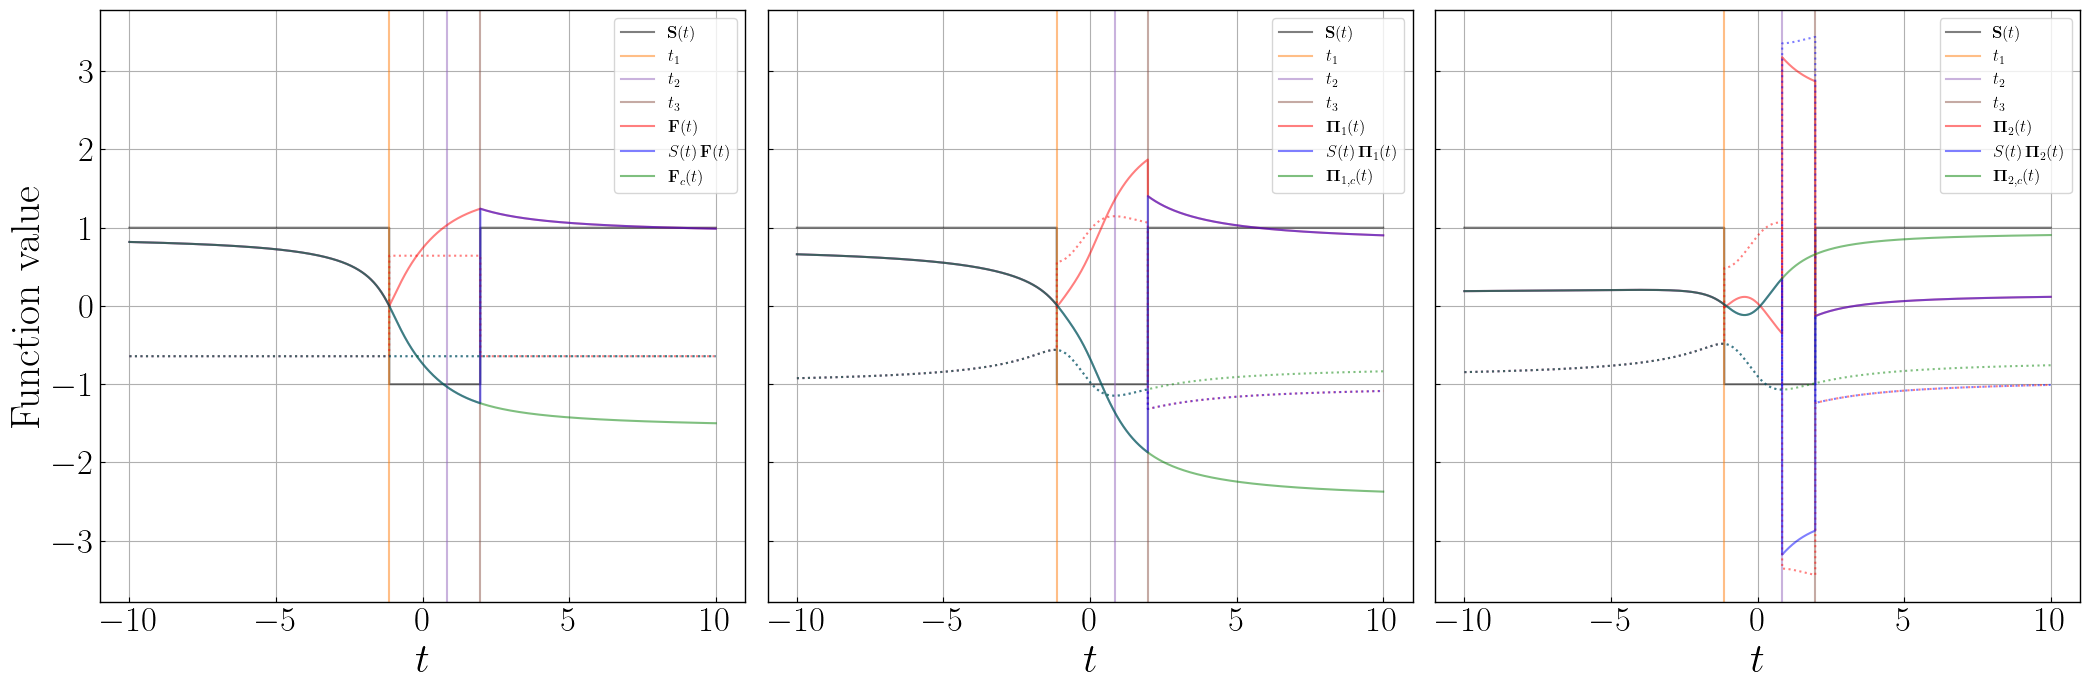

In [15]:
import matplotlib as mpl
mpl.rcParams['text.usetex'] = True
mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{bm}'


fig, ax = plt.subplots(1, 3, figsize=(21, 7), sharey=True)

c1, c2, c3 = 'tab:orange', 'tab:purple', 'tab:brown'

for i in range(3):
    ax[i].plot(t_vals, sgn_real, color='black', alpha=0.5, label=r'$\mathbf{S}(t)$')
    ax[i].axvline(t1, color=c1, alpha=0.5, label=r'$t_1$')
    ax[i].axvline(t2, color=c2, alpha=0.5, label=r'$t_2$')
    ax[i].axvline(t3, color=c3, alpha=0.5, label=r'$t_3$')

ax[0].plot(t_vals, f1_real, color='red', alpha=0.5, label=r'$\mathbf{F}(t)$')
ax[0].plot(t_vals, f1_imag, color='red', alpha=0.5, linestyle='dotted')
ax[1].plot(t_vals, pi1_real, color='red', alpha=0.5, label=r'$\boldsymbol{\Pi}_1(t)$')
ax[1].plot(t_vals, pi1_imag, color='red', alpha=0.5, linestyle='dotted')
ax[2].plot(t_vals, pi2_real, color='red', alpha=0.5, label=r'$\boldsymbol{\Pi}_2(t)$')
ax[2].plot(t_vals, pi2_imag, color='red', alpha=0.5, linestyle='dotted')

ax[0].plot(t_vals, sgn_real * f1_real, color='blue', alpha=0.5, label=r'$S(t)\,\mathbf{F}(t)$')
ax[0].plot(t_vals, sgn_real * f1_imag, color='blue', alpha=0.5, linestyle='dotted')
ax[1].plot(t_vals, sgn_real * pi1_real, color='blue', alpha=0.5, label=r'$S(t)\,\boldsymbol{\Pi}_1(t)$')
ax[1].plot(t_vals, sgn_real * pi1_imag, color='blue', alpha=0.5, linestyle='dotted')
ax[2].plot(t_vals, sgn_real * pi2_real, color='blue', alpha=0.5, label=r'$S(t)\,\boldsymbol{\Pi}_2(t)$')
ax[2].plot(t_vals, sgn_real * pi2_imag, color='blue', alpha=0.5, linestyle='dotted')

ax[0].plot(t_vals, cf1_real,  color='green', alpha=0.5, label=r'$\mathbf{F}_{c}(t)$')
ax[0].plot(t_vals, cf1_imag,  color='green', alpha=0.5, linestyle='dotted')
ax[1].plot(t_vals, cpi1_real, color='green', alpha=0.5, label=r'$\boldsymbol{\Pi}_{1,c}(t)$')
ax[1].plot(t_vals, cpi1_imag, color='green', alpha=0.5, linestyle='dotted')
ax[2].plot(t_vals, cpi2_real, color='green', alpha=0.5, label=r'$\boldsymbol{\Pi}_{2,c}(t)$')
ax[2].plot(t_vals, cpi2_imag, color='green', alpha=0.5, linestyle='dotted')

for i in range(3):
    ax[i].legend(loc='upper right', fontsize='large')
    ax[i].set_xlabel(r'$t$')

ax[0].set_ylabel(r'$\mathrm{Function\ value}$')

ax[0].grid()
ax[1].grid()
ax[2].grid()
plt.tight_layout()
plt.savefig("Continunity_Conditions.png")
plt.show()